# Factoring and Shor's Algorithm

[Official documentation](https://qualtran.readthedocs.io/en/latest/bloqs/cryptography/rsa/factoring-via-modexp.html)

### References

### Walk Through the Factoring of 13 × 17

In [1]:
import numpy as np

N = 13*17
n = int(np.ceil(np.log2(N)))
N, n

(221, 8)

In [2]:
g = 8
g

8

In [3]:
for e in range(20):
    f = (g ** e) % N

    star = ' *' if f == 1 else ''
    print(f'{e:5d} {f:5d}{star}')

    0     1 *
    1     8
    2    64
    3    70
    4   118
    5    60
    6    38
    7    83
    8     1 *
    9     8
   10    64
   11    70
   12   118
   13    60
   14    38
   15    83
   16     1 *
   17     8
   18    64
   19    70


In [4]:
period = 8

In [6]:
assert period % 2 == 0
assert g**(period//2) != -1

half_period = g**(period//2)
p1 = half_period + 1
m1 = half_period - 1

assert (p1*m1) % N == 0
print(f'gcd{p1%N, N}, gcd{m1%N, N}')
import math
math.gcd(p1%N, N), math.gcd(m1%N, N)

gcd(119, 221), gcd(117, 221)


(17, 13)

### Using the ModExp Bloq

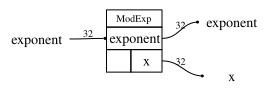

In [7]:
from qualtran.bloqs.cryptography.rsa.rsa_mod_exp import ModExp
from qualtran.drawing import show_bloq

mod_exp = ModExp(base=g, mod=N, exp_bitsize=32, x_bitsize=32)
show_bloq(mod_exp)

In [8]:
mod_exp_decomp = mod_exp.decompose_bloq()
mod_exp_decomp.bloq_counts()

{IntState(val=1, bitsize=32): 1,
 Split(dtype=QUInt(bitsize=32)): 1,
 CModMulK(dtype=QUInt(bitsize=32), k=8, mod=221): 1,
 CModMulK(dtype=QUInt(bitsize=32), k=64, mod=221): 1,
 CModMulK(dtype=QUInt(bitsize=32), k=118, mod=221): 1,
 CModMulK(dtype=QUInt(bitsize=32), k=1, mod=221): 29,
 Join(dtype=QUInt(bitsize=32)): 1}

In [9]:
from qualtran import QUInt
for e in range(20):
    ref = (g ** e) % N
    _, bloq_eval = mod_exp.call_classically(exponent=e)
    _, decomp_eval = mod_exp_decomp.call_classically(exponent=e)
    
    star = ' *' if ref == 1 else ''
    print(f'{e:5d} {ref:5d} {bloq_eval:5d} {decomp_eval:5d} {star}')

    0     1     1     1  *
    1     8     8     8 
    2    64    64    64 
    3    70    70    70 
    4   118   118   118 
    5    60    60    60 
    6    38    38    38 
    7    83    83    83 
    8     1     1     1  *
    9     8     8     8 
   10    64    64    64 
   11    70    70    70 
   12   118   118   118 
   13    60    60    60 
   14    38    38    38 
   15    83    83    83 
   16     1     1     1  *
   17     8     8     8 
   18    64    64    64 
   19    70    70    70 
